In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### # Step 1 - Load data and set correct date fat

In [2]:
df=sns.load_dataset('flights')
print(df.head)

<bound method NDFrame.head of      year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]>


In [3]:
# We get only year and month for the date, we need day also
# Convert a date to a YYYY-MM-DD format

df['yearMonth']= "01-"+df['month'].astype(str)+"-"+df['year'].astype(str)
print(df.info())
df['yearMonth']=pd.to_datetime("01-"+df['month'].astype(str)+"-"+df['year'].astype(str))
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
 3   yearMonth   144 non-null    str     
dtypes: category(1), int64(2), str(1)
memory usage: 4.0 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   yearMonth   144 non-null    datetime64[us]
dtypes: category(1), datetime64[us](1), int64(2)
memory usage: 4.0 KB
None
   year month  passengers  yearMonth
0  1949   Jan         112 1949-01-01
1  1949   Feb         118 1949-02-01
2  1949   Mar         13

In [4]:
# Make yearMonth coln as dataframe index
df.set_index('yearMonth',inplace=True) # inplce will make the change permanent to DF
print(df.head())

            year month  passengers
yearMonth                         
1949-01-01  1949   Jan         112
1949-02-01  1949   Feb         118
1949-03-01  1949   Mar         132
1949-04-01  1949   Apr         129
1949-05-01  1949   May         121


#### Step 2 - Vsualize the time series

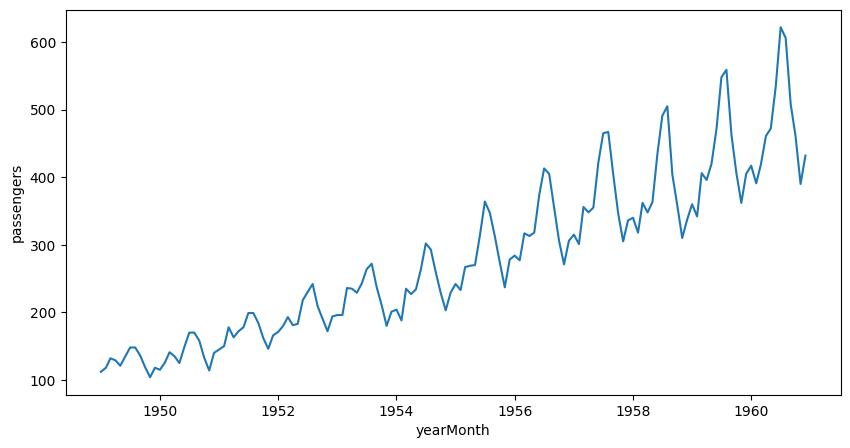

In [5]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index,y=df.passengers)
plt.show()

In [6]:
!pip install statsmodels

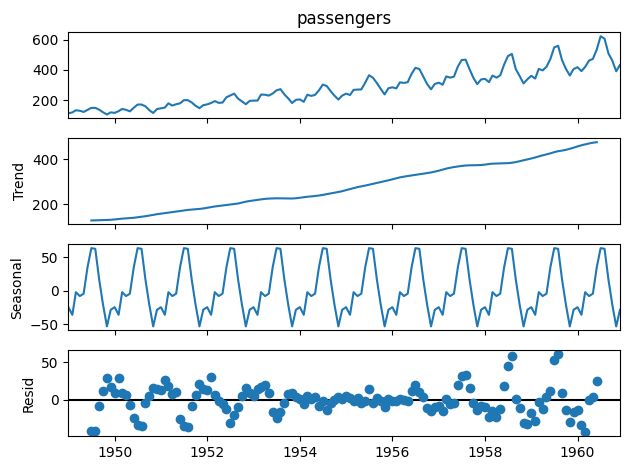

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt


decomposition = seasonal_decompose(df.passengers, period=12)
fig = decomposition.plot()

plt.show()

##### 

## Checking Stationarity

In [32]:
from statsmodels.tsa.stattools import adfuller

            passengers
yearMonth             
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]
ADF p_value: 0.9919
The time series is not stationary (fail to reject H0)


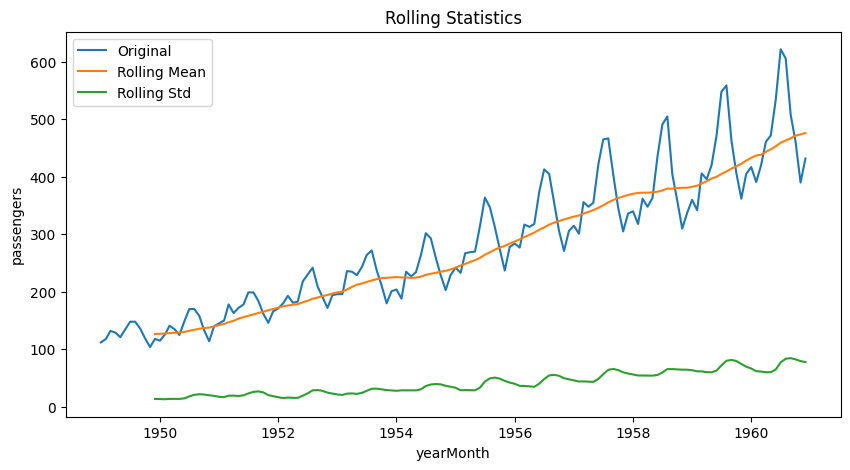

In [33]:
airP = df [['passengers']].copy(deep=True)
print(airP)

# Stationary Check
def test_stationarity(dataFrame, var, window=12):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=window).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=window).std()
    adf_result = adfuller(dataFrame[var])
    p_value = adf_result[1]

    print(f'ADF p_value: {p_value:.4f}')

    if p_value < 0.05:
        print('The time series is stationary (reject H0)')
    else:
        print('The time series is not stationary (fail to reject H0)')

    plt.figure(figsize=(10,5))
    sns.lineplot(x=dataFrame.index, y=dataFrame[var], label='Original')
    sns.lineplot(x=dataFrame.index, y=dataFrame['rollMean'], label='Rolling Mean')
    sns.lineplot(x=dataFrame.index, y=dataFrame['rollStd'], label='Rolling Std')
    plt.title('Rolling Statistics')
    plt.legend()
    plt.show()

# Test Stationarity
test_stationarity(airP, 'passengers')



#### Diff method


            passengers    rollMean    rollStd  shift  shiftDiff
yearMonth                                                      
1949-01-01         112         NaN        NaN    NaN        NaN
1949-02-01         118         NaN        NaN  112.0        6.0
1949-03-01         132         NaN        NaN  118.0       14.0
1949-04-01         129         NaN        NaN  132.0       -3.0
1949-05-01         121         NaN        NaN  129.0       -8.0
1949-06-01         135         NaN        NaN  121.0       14.0
1949-07-01         148         NaN        NaN  135.0       13.0
1949-08-01         148         NaN        NaN  148.0        0.0
1949-09-01         136         NaN        NaN  148.0      -12.0
1949-10-01         119         NaN        NaN  136.0      -17.0
1949-11-01         104         NaN        NaN  119.0      -15.0
1949-12-01         118  126.666667  13.720147  104.0       14.0
1950-01-01         115  126.916667  13.453342  118.0       -3.0
1950-02-01         126  127.583333  13.1

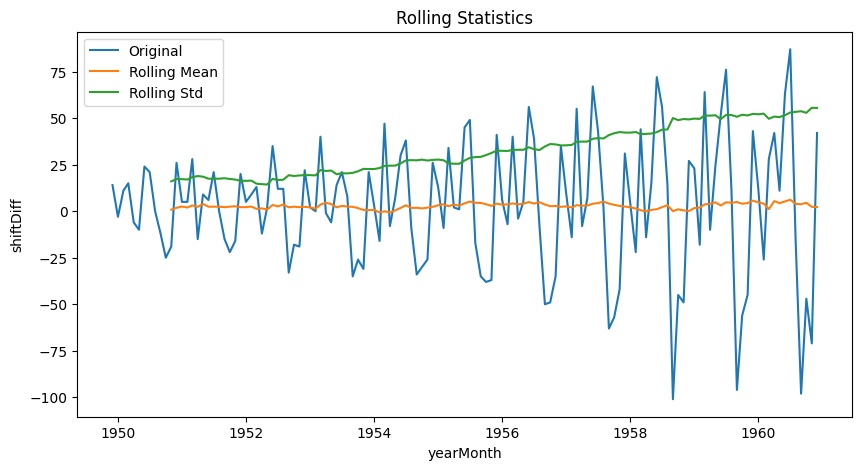

In [35]:
# passengers    shift[1]
# 112              -
# 118              112
# 132              118

# Data is not stationary - let us try "diff" method
airP['shift'] = airP.passengers.shift(1)
airP['shiftDiff'] = airP['passengers'] - airP['shift']
print(airP+.head(20))
test_stationarity(airP.dropna(), 'shiftDiff') 

            passengers    rollMean    rollStd  shift  shiftDiff
yearMonth                                                      
1949-01-01         112         NaN        NaN    NaN        NaN
1949-02-01         118         NaN        NaN    NaN        NaN
1949-03-01         132         NaN        NaN  112.0       20.0
1949-04-01         129         NaN        NaN  118.0       11.0
1949-05-01         121         NaN        NaN  132.0      -11.0
1949-06-01         135         NaN        NaN  129.0        6.0
1949-07-01         148         NaN        NaN  121.0       27.0
1949-08-01         148         NaN        NaN  135.0       13.0
1949-09-01         136         NaN        NaN  148.0      -12.0
1949-10-01         119         NaN        NaN  148.0      -29.0
1949-11-01         104         NaN        NaN  136.0      -32.0
1949-12-01         118  126.666667  13.720147  119.0       -1.0
1950-01-01         115  126.916667  13.453342  104.0       11.0
1950-02-01         126  127.583333  13.1

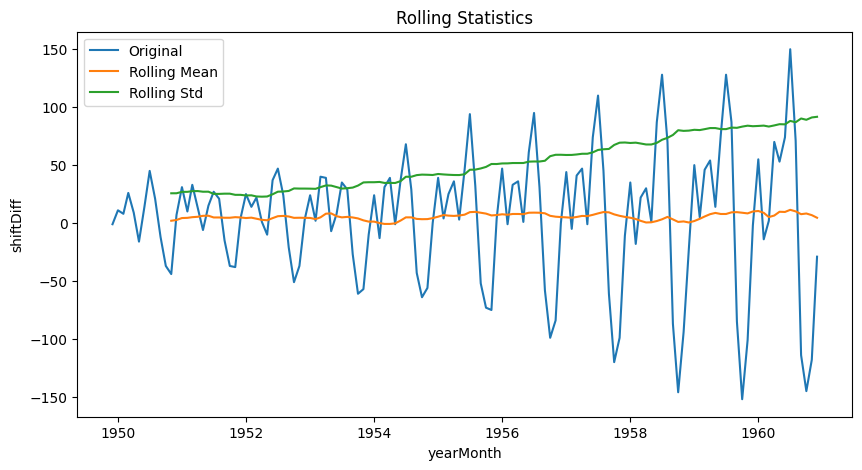

In [37]:
# Still the data is not stationary - increase shift by 2
# first two values will be dropped
# Data is not stationary - let us try "diff" method
airP['shift'] = airP.passengers.shift(2)
airP['shiftDiff'] = airP['passengers'] - airP['shift']
print(airP.head(20))
test_stationarity(airP.dropna(), 'shiftDiff') 

# ARIMA

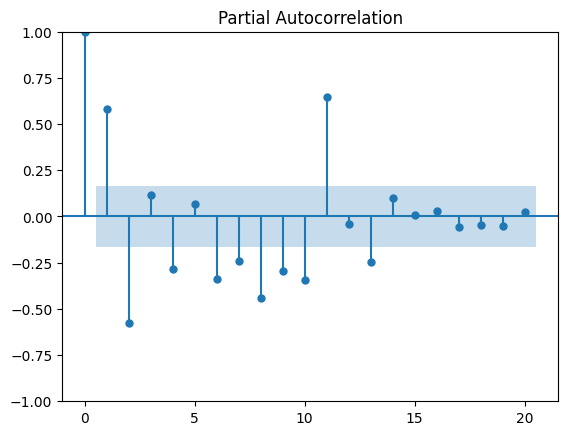

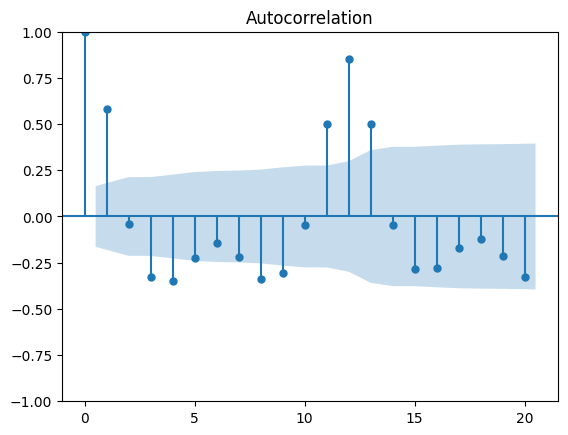

In [39]:
# ARIMA function: needs 3 parameters: p,d,q
airP['secondDiff'] = airP['passengers'].diff(2)  # do which is done manually in shift
airP["Diff(12)"] = airP['passengers'].diff(12)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# PACF plot (gives us 'p' in ARIMA)
plot_pacf(airP['secondDiff'].dropna(), lags=20)
plt.show()

# ACF plot (gives us 'q' in ARIMA)
plot_acf(airP['secondDiff'].dropna(), lags=20)
plt.show()

#lag 20 = we go 20 months back in past
## PACF
# highlighted area(coloured) = does the impact happened or not
# first line is current month, how much it is influenced by past month is checked
# e.g. april current month march has positive influence, feb has negative influence , jan has no influence, so on
# beyond 12 months it is meaningless

## ACF
# jan will impact feb + feb will impact march + march will impact April === aggregate Impact

##

#### Train-Test Spilt

In [40]:
train_size=int(len(airP) * 0.7) # First 70% in training
train=airP.iloc[:train_size]
test=airP.iloc[train_size:] # Reamining 30% in test

#### ARIMA Model

In [45]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_arima = ARIMA(train['passengers'],order=(1,2,1)) #pdq
model_arima_fit = model_arima.fit()
arima_pred = model_arima_fit.predict(start=len(train), end=len(airP)-1) # Use test set to predict---last of train data upto end of data

#Add ARIMA prediction to dataframe
airP['arimaPred']=np.nan # First set all to null
airP.iloc[train_size:, airP.columns.get_loc('arimaPred')]=arima_pred.values # Now add predictions only to test set----ignore train data
print(airP.tail()) # Compare actual with predcted by ARIMA


## Conclusion : ARIMA predictions are bad. Solution : Use SARIMAX

            passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  \
yearMonth                                                                     
1960-08-01         606  463.333333  83.630500  535.0       71.0        71.0   
1960-09-01         508  467.083333  84.617276  622.0     -114.0      -114.0   
1960-10-01         461  471.583333  82.541954  606.0     -145.0      -145.0   
1960-11-01         390  473.916667  79.502382  508.0     -118.0      -118.0   
1960-12-01         432  476.166667  77.737125  461.0      -29.0       -29.0   

            Diff(12)   arimaPred  
yearMonth                         
1960-08-01      47.0  439.708768  
1960-09-01      45.0  442.074513  
1960-10-01      54.0  444.440259  
1960-11-01      28.0  446.806004  
1960-12-01      27.0  449.171750  


C:\Users\PGCP-AI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\PGCP-AI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\PGCP-AI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### SARIMAX Model

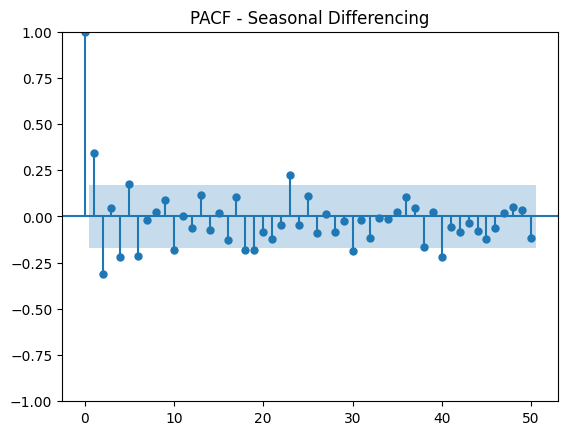

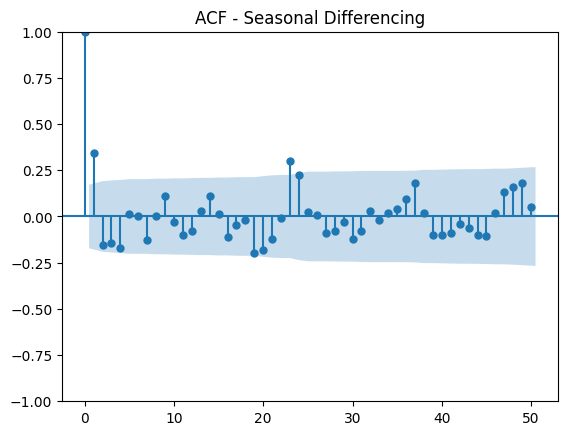

C:\Users\PGCP-AI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\PGCP-AI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  \
yearMonth                                                                     
1959-05-01         420  397.083333  60.008270  406.0       14.0        14.0   
1959-06-01         472  400.166667  63.009138  396.0       76.0        76.0   
1959-07-01         548  404.916667  71.987951  420.0      128.0       128.0   
1959-08-01         559  409.416667  80.049369  472.0       87.0        87.0   
1959-09-01         463  414.333333  81.485451  548.0      -85.0       -85.0   
1959-10-01         407  418.333333  79.680422  559.0     -152.0      -152.0   
1959-11-01         362  422.666667  74.498729  463.0     -101.0      -101.0   
1959-12-01         405  428.333333  69.830097  407.0       -2.0        -2.0   
1960-01-01         417  433.083333  66.624399  362.0       55.0        55.0   
1960-02-01         391  437.166667  61.866180  405.0      -14.0       -14.0   
1960-03-01         419  438.250000  61.382741  417.0

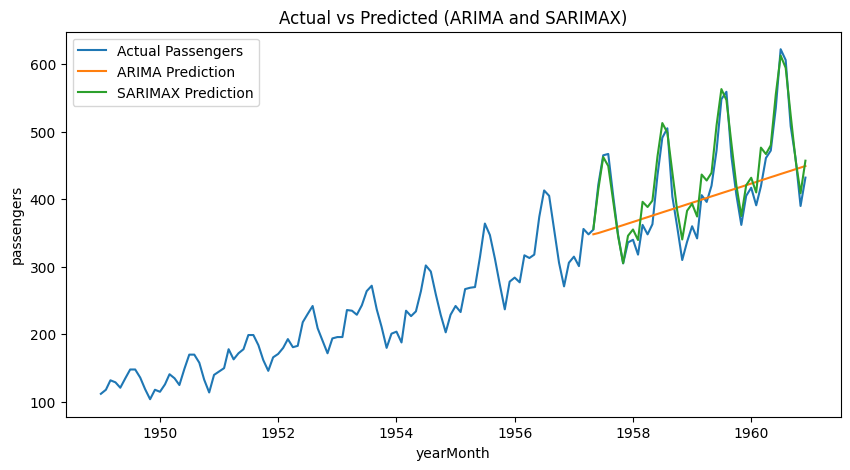

In [50]:
# To calculate P and Q SARIMAX

airP['diff_combined'] = airP['passengers'].diff(2).diff(12)
plot_pacf(airP['diff_combined'].dropna(),lags=50)
plt.title("PACF - Seasonal Differencing")
plt.show()

plot_acf(airP['diff_combined'].dropna(), lags=50)
plt.title("ACF - Seasonal Differencing")
plt.show()

model_sarimax = SARIMAX(train['passengers'],order=(1,2,1),seasonal_order=(1,2,1,12))
model_sarimax_fit=model_sarimax.fit()
sarimax_pred = model_sarimax_fit.predict(start=len(train), end=len(airP)-1)

# Add SARIMAX prediction to dataframe
airP['sarimaxPred']=np.nan
airP.iloc[train_size:,airP.columns.get_loc('sarimaxPred')]=sarimax_pred.values
print(airP.tail(20))

# Plot Predictions
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index, y=airP['passengers'], label='Actual Passengers')
sns.lineplot(x=airP.index, y=airP['arimaPred'], label ='ARIMA Prediction')
sns.lineplot(x=airP.index, y=airP['sarimaxPred'], label ='SARIMAX Prediction')
plt.title('Actual vs Predicted (ARIMA and SARIMAX)')
plt.legend()
plt.show()

1961-01-01    468.930594
1961-02-01    444.067710
1961-03-01    515.025258
1961-04-01    504.546331
1961-05-01    519.272923
1961-06-01    599.658586
1961-07-01    660.643133
1961-08-01    640.478226
1961-09-01    564.491452
1961-10-01    494.154981
1961-11-01    440.992989
1961-12-01    491.735096
1962-01-01    504.316554
1962-02-01    476.354489
1962-03-01    551.715224
1962-04-01    540.280201
1962-05-01    556.585088
1962-06-01    642.032033
1962-07-01    706.534402
1962-08-01    684.276786
1962-09-01    602.452557
1962-10-01    527.354197
1962-11-01    470.623666
1962-12-01    523.908600
Freq: MS, Name: predicted_mean, dtype: float64


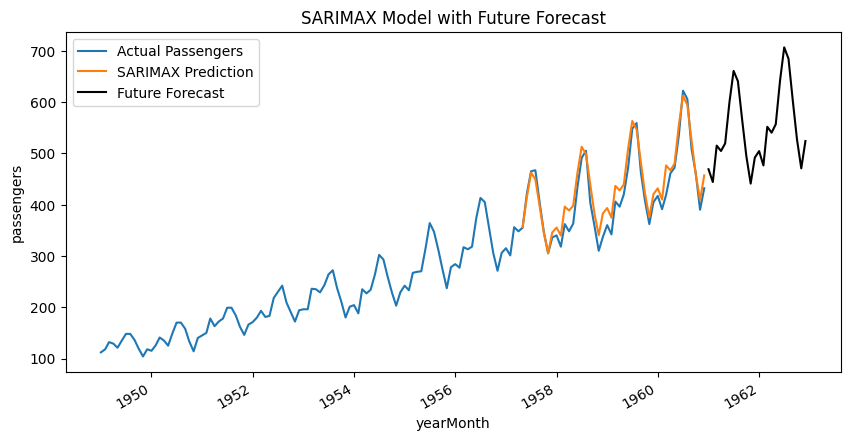

ARIMA -> MAE : 53.92, RMSE: 70.99, R^2 : 0.14
SARIMAX-> MAE : 19.75, RMSE: 23.60, R^2 : 0.90


In [53]:
# Future Forecast using SARIMAX

future_dates = pd.DataFrame(pd.date_range(start='1961-01-01', end='1962-12-01',freq='MS'), columns=['Dates'])
future_dates.set_index('Dates', inplace=True)

future_forecast= model_sarimax_fit.predict(start=future_dates.index[0], end=future_dates.index[-1])
print(future_forecast)

# Plot Future Forecast
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index, y=airP['passengers'], label='Actual Passengers')
sns.lineplot(x=airP.index, y=airP['sarimaxPred'], label='SARIMAX Prediction')
future_forecast.plot(color='black', label='Future Forecast')
plt.title('SARIMAX Model with Future Forecast')
plt.legend()
plt.show()

# Model Evalution 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
airP = airP.dropna()

#ARIMA Metrics
arima_mae = mean_absolute_error(airP['passengers'], airP['arimaPred'])
arima_mse = mean_squared_error(airP['passengers'], airP['arimaPred'])
arima_rmse = math.sqrt(arima_mse)
arima_r2 = r2_score(airP['passengers'], airP['arimaPred'])
print(f"ARIMA -> MAE : {arima_mae:.2f}, RMSE: {arima_rmse:.2f}, R^2 : {arima_r2:.2f}")

# SARIMA Metrics
sarimax_mae = mean_absolute_error(airP['passengers'], airP['sarimaxPred'])
sarimax_mse = mean_squared_error(airP['passengers'], airP['sarimaxPred'])
sarimax_rmse = math.sqrt(sarimax_mse)
sarimax_r2 = r2_score(airP['passengers'], airP['sarimaxPred'])
print(f"SARIMAX-> MAE : {sarimax_mae:.2f}, RMSE: {sarimax_rmse:.2f}, R^2 : {sarimax_r2:.2f}")
